# QuantumCircuit + Core 函数教程

本教程目标：
1. 先用高层接口 `run_auto` 快速跑通（固定 `Simulator`）。
2. 再把同一流程拆开：手动构造测量线路，并且全部通过 `simulate_counts` 采样。

这样可以让你同时掌握“业务调用层”和“优化改造层”。

In [1]:
from quantum_hw import QuantumHardwareClient, QuantumCircuit
from quantum_hw.core.observables import group_observables, append_measurement_basis, pauli_expectation
from quantum_hw.core.utils import get_samples, get_probabilities_from_samples
from quantum_hw.sim.statevector import simulate_counts

import numpy as np

def section(title: str):
    print("\n" + "=" * 18, title, "=" * 18)

## 1) 用 QuantumCircuit 手动搭一条线路

这里构造一个 6 比特 GHZ 风格线路，后续两种流程都复用它。

In [2]:
section("build circuit")
num_qubits = 6
qc = QuantumCircuit(num_qubits)
qc.h(0)
for i in range(num_qubits - 1):
    qc.cx(i, i + 1)

observables = ["ZZIIII", "IIZZII", "IIXXII"]

print("gate count:", len(qc.gates))
print("observables:", observables)


================== build circuit ==================
gate count: 6
observables: ['ZZIIII', 'IIZZII', 'IIXXII']


## 2) 高层：直接调用 `run_auto`（Simulator）

这是推荐给普通用户的入口：自动处理编译、分组、采样和观测量计算。

In [3]:
section("run_auto (high-level)")
client = QuantumHardwareClient()

result_auto = client.run_auto(
    circuit=qc,
    name="tutorial_circuit_core_auto",
    num_qubits=num_qubits,
    shots=2048,
    observables=observables,
    return_probabilities=True,
    prefer_chips="Simulator",
    print_true=False,
)

print("observable_values:", result_auto.observable_values)
print("num groups in samples:", len(result_auto.samples))


================== run_auto (high-level) ==================
observable_values: {'ZZIIII': 1.0, 'IIZZII': 1.0, 'IIXXII': 0.0146484375}
num groups in samples: 2


# 3) 真实实验
结合ZNE和read-out error mitigation


================== Experiments ==================
observable_values: {'ZZIIII': 1.0058798592549025, 'IIZZII': 0.919713180501152, 'IIXXII': 0.03371891369574602}
observable_values_raw: {'ZZIIII': 0.88671875, 'IIZZII': 0.740234375, 'IIXXII': 0.0166015625}


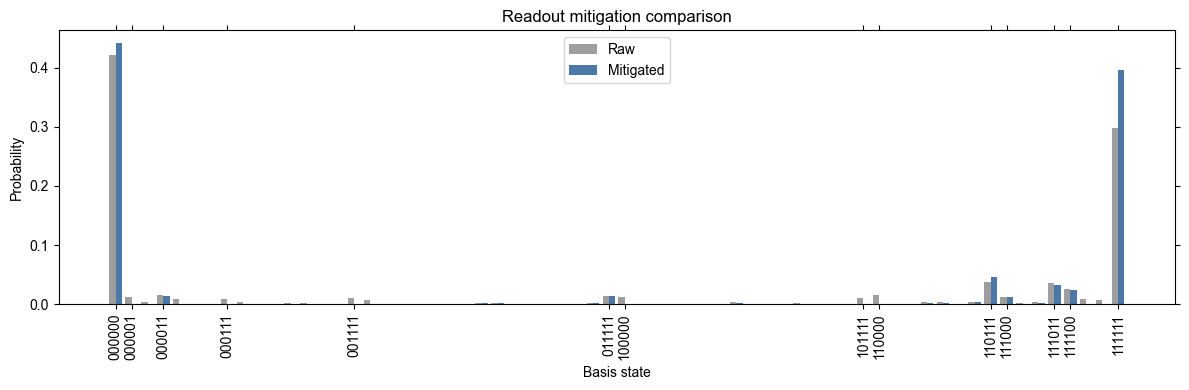

In [ ]:
from quantum_hw.core.plotting import plot_probabilities_compare
section("Experiments")
client = QuantumHardwareClient()

result_auto = client.run_auto(
    circuit=qc,
    name="tutorial_circuit_core_auto",
    num_qubits=num_qubits,
    shots=2048,
    observables=observables,
    return_probabilities=True,
    prefer_chips="gd_qc1",
    provider="guodun",
    print_true=False,
    zne=True,
    readout_mitigation=True
)

print("observable_values:", result_auto.observable_values)
print("observable_values_raw:", result_auto.observable_values_raw)
plot_probabilities_compare(result_auto.probabilities_raw, result_auto.probabilities, num_qubits)

## 4) 拆解版：手动分组与测量线路

这里直接调用 core 函数：
- `group_observables`：把可同时测量的 observables 合并到同一测量基
- `append_measurement_basis`：对线路附加基旋转 + 测量
- `simulate_counts`：用状态矢量模拟器采样 counts
- `get_samples` / `get_probabilities_from_samples` / `pauli_expectation`：后处理

In [5]:
section("manual pipeline with simulate_counts")
shots = 2048
groups = group_observables(observables, num_qubits=num_qubits)

print("group count:", len(groups))
for i, g in enumerate(groups):
    print(f"group {i}: basis={g['basis']}, observables={g['observables']}")

samples_by_group = []
probs_by_group = []
obs_manual = {}

for gi, group in enumerate(groups):
    qc_meas = qc.deepcopy()
    basis_pattern = group["basis"]
    append_measurement_basis(qc_meas, basis_pattern, target_qubits=list(range(num_qubits)))

    counts = simulate_counts(qc_meas, shots=shots, seed=1000 + gi)
    samples = get_samples(counts, num_qubits=num_qubits)
    probs = get_probabilities_from_samples(samples, num_qubits=num_qubits)

    samples_by_group.append(samples)
    probs_by_group.append(probs)

    for obs in group["observables"]:
        obs_manual[obs] = pauli_expectation(samples, obs)

print("manual observable values:", obs_manual)
print("manual first prob vector length:", probs_by_group[0].shape[0])


================== manual pipeline with simulate_counts ==================
group count: 2
group 0: basis=['Z', 'Z', 'Z', 'Z', 'I', 'I'], observables=['ZZIIII', 'IIZZII']
group 1: basis=['I', 'I', 'X', 'X', 'I', 'I'], observables=['IIXXII']
manual observable values: {'ZZIIII': 1.0, 'IIZZII': 1.0, 'IIXXII': -0.01953125}
manual first prob vector length: 64


## 5) 你可以继续尝试

- 把 `qc` 换成 `client.build_circuit("qft", ...)` 结果做对比。
- 把 `observables` 换成带索引形式（例如 `"Z0 Z1"`）。
- 增大 `shots` 看 `run_auto` 与手动流程差异是否收敛。